# Fase 3 — Grad-CAM: Visualización de Regiones de Activación
## Proyecto Final IA · EAFIT 2026-1

**Objetivo:** Aplicar Gradient-weighted Class Activation Mapping (Grad-CAM) sobre el ResNet-50
entrenado para visualizar qué zonas de la hoja activan la predicción de cada enfermedad.

**Responsable principal:** Integrante 1 (P1) — visualizaciones, galería por clase  
**Apoyo:** Integrante 2 (P2) — descripción en texto de las zonas activas (input para Fase 4)

**Prerequisito:** `fase2_cnn_training.ipynb` completado. El modelo `best_resnet50.pth`
y `config_modelo.json` deben estar en **Google Drive/IA_EAFIT/artifacts/**.

---
> **Referencia:** Selvaraju et al. (2017). *Grad-CAM: Visual Explanations from Deep Networks
> via Gradient-based Localization.* ICCV. https://arxiv.org/abs/1610.02391


## 0. Setup — Drive, dependencias y restauración del modelo

In [1]:
!pip install -q grad-cam torch torchvision opencv-python-headless Pillow matplotlib
print('✅ Dependencias instaladas')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 60.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
✅ Dependencias instaladas


In [2]:
from google.colab import drive
from pathlib import Path
import shutil, json, zipfile

drive.mount('/content/drive')

# ── Rutas ─────────────────────────────────────────────────────────────────────
DRIVE_DIR       = Path('/content/drive/MyDrive/IA_EAFIT')
DRIVE_ARTIFACTS = DRIVE_DIR / 'artifacts'
DRIVE_FIGURES   = DRIVE_DIR / 'figures'
ARTIFACTS       = Path('/content/artifacts')
ARTIFACTS.mkdir(exist_ok=True)

# ── Funciones auxiliares ──────────────────────────────────────────────────────
def save_to_drive(local_path, subfolder='artifacts', verbose=True):
    local_path = Path(local_path)
    if not local_path.exists():
        if verbose: print(f'  ⚠️  No encontrado: {local_path}')
        return None
    dest = DRIVE_DIR / subfolder / local_path.name
    (DRIVE_DIR / subfolder).mkdir(exist_ok=True)
    shutil.copy2(local_path, dest)
    if verbose:
        print(f'  ✅ {local_path.name:40s} → Drive/{subfolder}/ ({dest.stat().st_size/1024:.1f} KB)')
    return dest

def load_from_drive(filename, subfolder='artifacts', dest_dir='/content/artifacts'):
    src = DRIVE_DIR / subfolder / filename
    if not src.exists():
        print(f'  ⚠️  No encontrado en Drive: {src}')
        return None
    dest = Path(dest_dir); dest.mkdir(parents=True, exist_ok=True)
    dest_file = dest / filename
    shutil.copy2(src, dest_file)
    print(f'  ✅ {filename} ← Drive/{subfolder}/')
    return dest_file

# ── Restaurar artefactos desde Drive ─────────────────────────────────────────
print('Restaurando artefactos desde Drive...')
load_from_drive('config_modelo.json',  'artifacts')
load_from_drive('config_fase1.json',   'artifacts')
load_from_drive('best_resnet50.pth',   'artifacts')

# ── Restaurar dataset_split si no existe ──────────────────────────────────────
SPLIT_DIR = Path('/content/dataset_split')
if not SPLIT_DIR.exists() or not any(SPLIT_DIR.rglob('*.jpg')):
    print('Restaurando dataset desde Drive...')
    load_from_drive('dataset_split.zip', 'dataset', '/content/artifacts')
    with zipfile.ZipFile(ARTIFACTS / 'dataset_split.zip', 'r') as zf:
        zf.extractall('/content')
    print(f'  ✅ dataset_split restaurado')
else:
    print(f'  ✅ dataset_split ya disponible')

print('\n✅ Setup completo')

Mounted at /content/drive
Restaurando artefactos desde Drive...
  ✅ config_modelo.json ← Drive/artifacts/
  ✅ config_fase1.json ← Drive/artifacts/
  ✅ best_resnet50.pth ← Drive/artifacts/
Restaurando dataset desde Drive...
  ✅ dataset_split.zip ← Drive/dataset/
  ✅ dataset_split restaurado

✅ Setup completo


## 1. Cargar modelo y configuración

In [3]:
import torch
import torch.nn as nn
from torchvision import models, transforms
import numpy as np

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

# ── Cargar configuración ──────────────────────────────────────────────────────
with open(ARTIFACTS / 'config_modelo.json') as f:
    cfg_model = json.load(f)
with open(ARTIFACTS / 'config_fase1.json') as f:
    cfg_fase1 = json.load(f)

CLASS_NAMES   = cfg_model['class_names']
N_CLASSES     = cfg_model['n_classes']
IMG_SIZE      = cfg_model['img_size']
IMAGENET_MEAN = cfg_model['imagenet_mean']
IMAGENET_STD  = cfg_model['imagenet_std']
MODEL_PATH    = ARTIFACTS / 'best_resnet50.pth'

print(f'Clases : {N_CLASSES}')
print(f'Clases : {CLASS_NAMES}')

# ── Reconstruir arquitectura idéntica a Fase 2 ───────────────────────────────
model = models.resnet50(weights=None)   # sin pesos — los cargamos a continuación
in_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(in_features, 512),
    nn.ReLU(),
    nn.Dropout(p=0.4),
    nn.Linear(512, N_CLASSES)
)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model = model.to(DEVICE)
model.eval()
print(f'\n✅ Modelo cargado desde {MODEL_PATH}')

# ── Transform para inferencia (sin augmentation) ─────────────────────────────
transform_eval = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# ── Helper: label legible ─────────────────────────────────────────────────────
def label_legible(class_name: str) -> str:
    """'Tomato___Late_blight' → 'Tomato / Late blight'"""
    parts = class_name.split('___')
    planta = parts[0].replace('_', ' ').strip()
    estado = parts[1].replace('_', ' ').strip() if len(parts) > 1 else ''
    return f'{planta} / {estado}' if estado else planta

IDX_TO_LABEL = {i: label_legible(c) for i, c in enumerate(CLASS_NAMES)}

Device: cuda
Clases : 6
Clases : ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Late_blight', 'Tomato_healthy']

✅ Modelo cargado desde /content/artifacts/best_resnet50.pth


## 2. Configurar Grad-CAM

**¿Por qué `layer4`?**  
Es la última capa convolucional de ResNet-50. Sus mapas de características tienen la resolución
espacial más baja (7×7) pero la semántica más alta — captura qué partes de la imagen activaron
la decisión de clasificación. Es el target estándar para Grad-CAM en ResNet.

Usamos **GradCAM++** (mejora de Grad-CAM original) que es más preciso para objetos pequeños
y múltiples instancias dentro de la misma imagen.

In [4]:
from pytorch_grad_cam import GradCAMPlusPlus, GradCAM, EigenCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import cv2

# ── Capa objetivo: última capa convolucional de ResNet-50 ─────────────────────
target_layers = [model.layer4[-1]]

# ── Instanciar GradCAM++ ──────────────────────────────────────────────────────
cam = GradCAMPlusPlus(model=model, target_layers=target_layers)

print('✅ GradCAM++ inicializado')
print(f'   Target layer: model.layer4[-1] (ResNet-50 Bottleneck)')
print(f'   Resolución del mapa CAM: 7×7 → interpolado a {IMG_SIZE}×{IMG_SIZE}')

✅ GradCAM++ inicializado
   Target layer: model.layer4[-1] (ResNet-50 Bottleneck)
   Resolución del mapa CAM: 7×7 → interpolado a 224×224


## 3. Función principal de inferencia + Grad-CAM

Esta función es el núcleo de la Fase 3 y también el puente con la Fase 4 (LLM):  
devuelve la predicción, la confianza, el heatmap superpuesto **y una descripción textual**
de la zona activa que el LLM usará como contexto.

In [5]:
from PIL import Image as PILImage
import torch.nn.functional as F

def describe_activation_zone(cam_mask: np.ndarray, threshold: float = 0.5) -> str:
    """
    Traduce un mapa de activación Grad-CAM a una descripción textual en español.
    Divide la imagen en una cuadrícula 3×3 y describe las zonas con mayor activación.
    Esta descripción se usará como contexto para el LLM en la Fase 4.

    Args:
        cam_mask:  Array 2D normalizado [0,1] con el mapa de calor.
        threshold: Umbral mínimo de activación para considerar una zona relevante.
    Returns:
        Descripción textual de las zonas activas.
    """
    h, w = cam_mask.shape
    rows = ['superior', 'central', 'inferior']
    cols = ['izquierda', 'centro',  'derecha']

    region_scores = {}
    for r_idx, row_name in enumerate(rows):
        for c_idx, col_name in enumerate(cols):
            r0, r1 = r_idx * h // 3, (r_idx + 1) * h // 3
            c0, c1 = c_idx * w // 3, (c_idx + 1) * w // 3
            score = cam_mask[r0:r1, c0:c1].mean()
            region_scores[f'{row_name}-{col_name}'] = float(score)

    # Zonas por encima del umbral, ordenadas de mayor a menor
    active = sorted(
        [(k, v) for k, v in region_scores.items() if v >= threshold],
        key=lambda x: -x[1]
    )

    if not active:
        # Si nada supera el umbral, tomar las 2 zonas con mayor activación
        active = sorted(region_scores.items(), key=lambda x: -x[1])[:2]

    # Intensidad global
    max_act = cam_mask.max()
    if max_act > 0.75:
        intensidad = 'alta'
    elif max_act > 0.45:
        intensidad = 'moderada'
    else:
        intensidad = 'difusa y distribuida'

    zonas_desc = ', '.join([z.replace('-', ' ') for z, _ in active[:3]])
    pct_activa = 100 * (cam_mask >= threshold).mean()

    descripcion = (
        f"Las regiones de mayor activación (Grad-CAM++) se concentran en la zona {zonas_desc} "
        f"de la imagen, con una intensidad {intensidad}. "
        f"Aproximadamente el {pct_activa:.0f}% del área de la hoja supera el umbral de activación."
    )
    return descripcion


def predict_with_gradcam(
    image_path: str,
    target_class: int = None,
    colormap: int = cv2.COLORMAP_JET,
    alpha: float = 0.45
) -> dict:
    """
    Realiza inferencia + Grad-CAM sobre una imagen.

    Args:
        image_path:   Ruta a la imagen (JPG, PNG).
        target_class: Índice de clase objetivo. Si None, usa la predicción del modelo.
        colormap:     Colormap OpenCV para el heatmap (JET, INFERNO, HOT, etc.).
        alpha:        Transparencia del heatmap sobre la imagen original (0=invisible, 1=opaco).

    Returns:
        dict con:
          - 'class_idx'       : índice de la clase predicha
          - 'class_name'      : nombre interno de la clase
          - 'class_label'     : etiqueta legible (ej. 'Tomato / Late blight')
          - 'confidence'      : confianza [0,1]
          - 'all_probs'       : probabilidades para todas las clases
          - 'cam_mask'        : mapa de calor normalizado (H×W)
          - 'overlay'         : imagen PIL con heatmap superpuesto
          - 'original'        : imagen PIL original
          - 'zone_description': descripción textual para el LLM
    """
    # 1. Cargar imagen
    img_pil = PILImage.open(image_path).convert('RGB')
    img_pil_resized = img_pil.resize((IMG_SIZE, IMG_SIZE), PILImage.LANCZOS)
    img_np = np.array(img_pil_resized) / 255.0   # float [0,1] para show_cam_on_image

    # 2. Tensor para el modelo
    tensor = transform_eval(img_pil_resized).unsqueeze(0).to(DEVICE)

    # 3. Inferencia
    with torch.no_grad():
        logits = model(tensor)
        probs  = F.softmax(logits, dim=1).cpu().numpy()[0]

    pred_idx  = int(probs.argmax())
    target_idx = target_class if target_class is not None else pred_idx
    targets    = [ClassifierOutputTarget(target_idx)]

    # 4. Grad-CAM
    cam_mask = cam(input_tensor=tensor, targets=targets)[0]   # (H, W) float32
    cam_mask = np.clip(cam_mask, 0, 1)

    # 5. Superponer heatmap
    overlay_np = show_cam_on_image(
        img_np.astype(np.float32),
        cam_mask,
        use_rgb=True,
        colormap=colormap,
        image_weight=1 - alpha
    )
    overlay_pil = PILImage.fromarray(overlay_np)

    # 6. Descripción de zona activa
    zone_desc = describe_activation_zone(cam_mask)

    return {
        'class_idx'       : pred_idx,
        'class_name'      : CLASS_NAMES[pred_idx],
        'class_label'     : IDX_TO_LABEL[pred_idx],
        'confidence'      : float(probs[pred_idx]),
        'all_probs'       : probs,
        'cam_mask'        : cam_mask,
        'overlay'         : overlay_pil,
        'original'        : img_pil_resized,
        'zone_description': zone_desc,
    }


print('✅ Funciones predict_with_gradcam() y describe_activation_zone() listas')

✅ Funciones predict_with_gradcam() y describe_activation_zone() listas


## 4. Prueba rápida — una imagen

Imagen: /content/dataset_split/test/Pepper__bell___healthy/6ff92031-6a52-47ba-91d0-3df19f11104c___JR_HL 7774.JPG


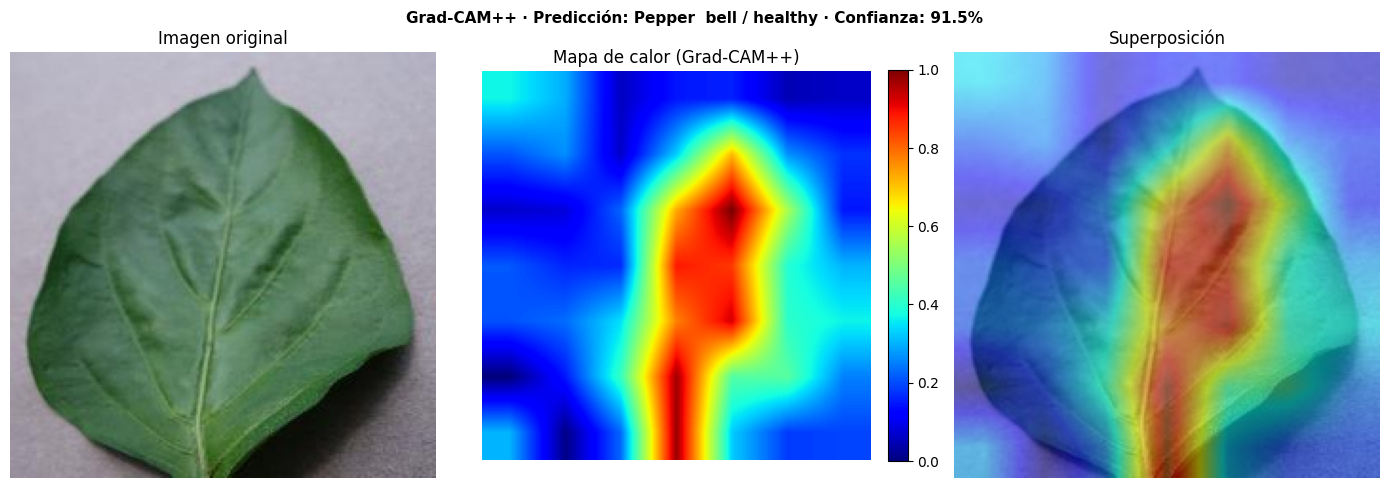


Descripción de zona activa (contexto para LLM):
  "Las regiones de mayor activación (Grad-CAM++) se concentran en la zona central centro, inferior centro de la imagen, con una intensidad alta. Aproximadamente el 23% del área de la hoja supera el umbral de activación."


In [6]:
import random, matplotlib.pyplot as plt

random.seed(42)

# Tomar una imagen aleatoria del test set
test_imgs = list((SPLIT_DIR / 'test').rglob('*.jpg')) + \
            list((SPLIT_DIR / 'test').rglob('*.JPG')) + \
            list((SPLIT_DIR / 'test').rglob('*.png'))
sample_path = random.choice(test_imgs)

print(f'Imagen: {sample_path}')
result = predict_with_gradcam(str(sample_path))

# Mostrar resultado
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle(
    f'Grad-CAM++ · Predicción: {result["class_label"]} · '
    f'Confianza: {result["confidence"]*100:.1f}%',
    fontsize=11, fontweight='bold'
)

axes[0].imshow(result['original'])
axes[0].set_title('Imagen original')
axes[0].axis('off')

im = axes[1].imshow(result['cam_mask'], cmap='jet', vmin=0, vmax=1)
axes[1].set_title('Mapa de calor (Grad-CAM++)')
axes[1].axis('off')
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

axes[2].imshow(result['overlay'])
axes[2].set_title('Superposición')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print(f'\nDescripción de zona activa (contexto para LLM):')
print(f'  "{result["zone_description"]}"')

## 5. Galería completa — 3 ejemplos por clase

Genera la figura principal de Grad-CAM del informe: para cada clase, muestra
imagen original + heatmap + superposición.

Guardando galería...


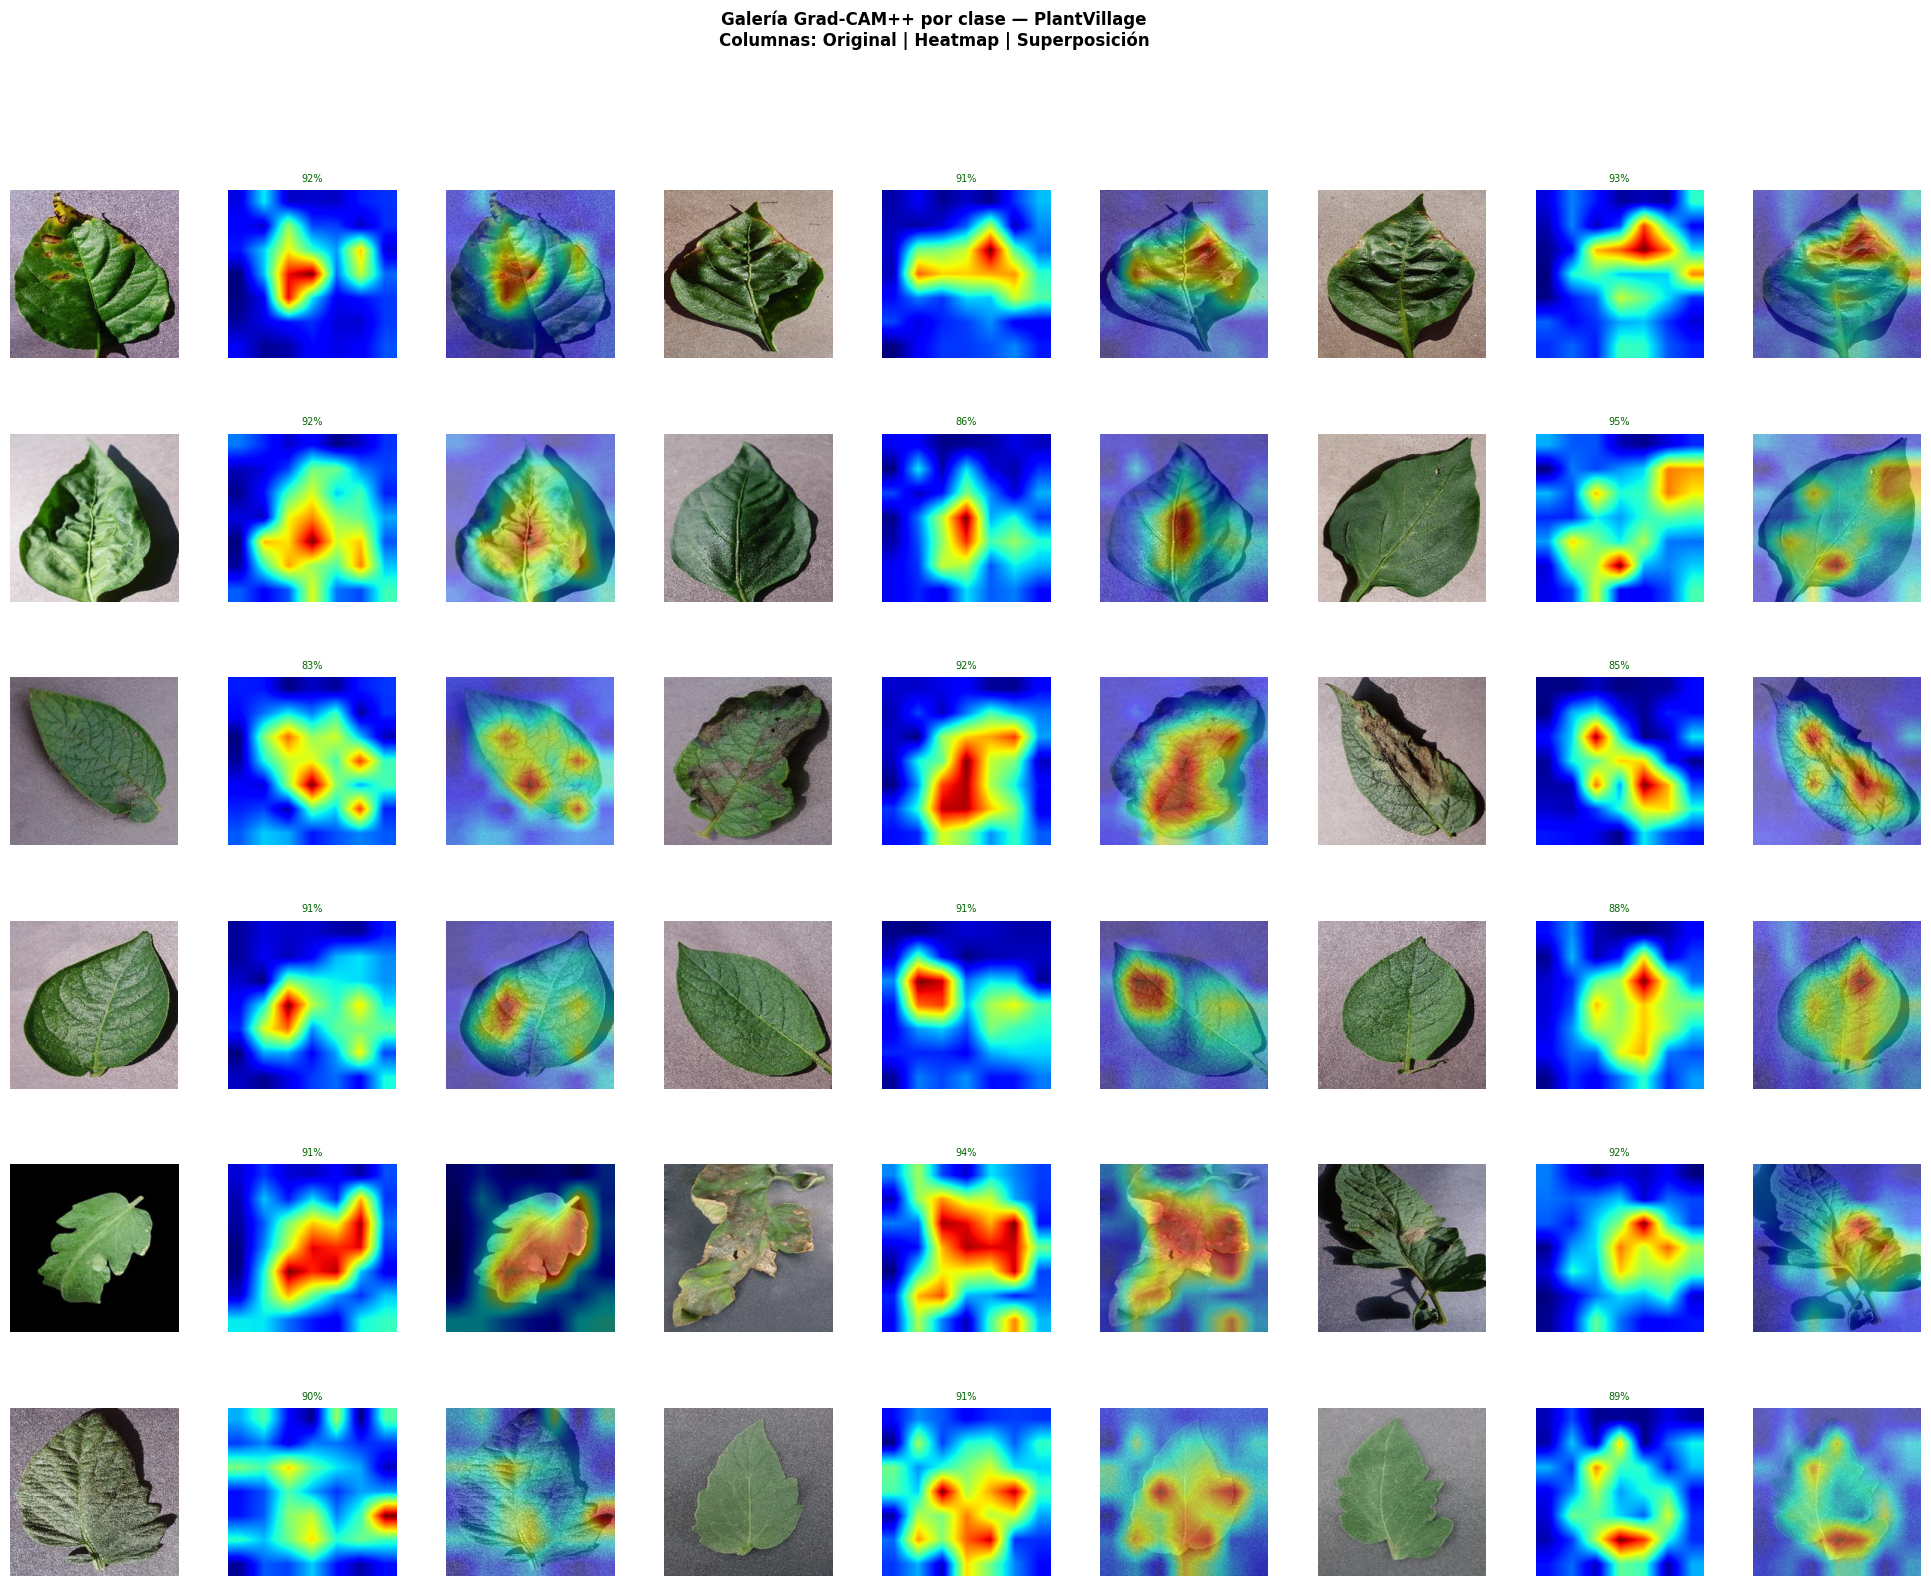

✅ fig8_gradcam_gallery.png guardada


In [7]:
import random, matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

random.seed(42)

N_PER_CLASS = 3   # imágenes por clase en la galería
classes_in_test = sorted([d.name for d in (SPLIT_DIR / 'test').iterdir() if d.is_dir()])
N_CLASSES_VIZ = len(classes_in_test)

# ── Layout: N_CLASSES_VIZ filas × (N_PER_CLASS * 3) columnas ─────────────────
# Cada ejemplo ocupa 3 columnas: original | heatmap | overlay
n_cols = N_PER_CLASS * 3
fig = plt.figure(figsize=(n_cols * 2.8, N_CLASSES_VIZ * 3.0))
fig.suptitle(
    'Galería Grad-CAM++ por clase — PlantVillage\n'
    'Columnas: Original | Heatmap | Superposición',
    fontsize=12, fontweight='bold'
)

outer = gridspec.GridSpec(N_CLASSES_VIZ, 1, figure=fig, hspace=0.45)

for row_idx, clase in enumerate(classes_in_test):
    clase_dir = SPLIT_DIR / 'test' / clase
    imgs = list(clase_dir.glob('*.jpg')) + list(clase_dir.glob('*.JPG')) + \
           list(clase_dir.glob('*.png'))
    muestra = random.sample(imgs, min(N_PER_CLASS, len(imgs)))

    inner = gridspec.GridSpecFromSubplotSpec(
        1, n_cols, subplot_spec=outer[row_idx], wspace=0.04
    )

    color_fila = '#1a6b35' if 'healthy' in clase.lower() else '#8b1a1a'

    for img_idx, img_path in enumerate(muestra):
        try:
            res = predict_with_gradcam(str(img_path))
        except Exception as e:
            print(f'  ⚠️  Error en {img_path.name}: {e}')
            continue

        col_base = img_idx * 3

        # Original
        ax0 = fig.add_subplot(inner[0, col_base])
        ax0.imshow(res['original'])
        ax0.axis('off')
        if img_idx == 0:
            etiqueta = label_legible(clase)
            ax0.set_ylabel(etiqueta, fontsize=8, color=color_fila,
                           fontweight='bold', rotation=0, labelpad=80, va='center')

        # Heatmap
        ax1 = fig.add_subplot(inner[0, col_base + 1])
        ax1.imshow(res['cam_mask'], cmap='jet', vmin=0, vmax=1)
        ax1.axis('off')
        conf_str = f"{res['confidence']*100:.0f}%"
        match_color = 'darkgreen' if res['class_name'] == clase else 'red'
        ax1.set_title(conf_str, fontsize=7, color=match_color)

        # Overlay
        ax2 = fig.add_subplot(inner[0, col_base + 2])
        ax2.imshow(res['overlay'])
        ax2.axis('off')

print('Guardando galería...')
plt.savefig('/content/fig8_gradcam_gallery.png', dpi=130, bbox_inches='tight')
plt.show()
print('✅ fig8_gradcam_gallery.png guardada')

## 6. Análisis comparativo — misma planta, sana vs enferma

Comparación directa de Grad-CAM entre la versión sana y enferma de cada cultivo.
Muestra cómo el modelo activa zonas distintas según el estado de la planta —
hallazgo clave para incluir en la sección de discusión del informe.

Pares encontrados: 2
  • Pepper  bell / healthy         ↔ Pepper  bell / Bacterial spot
  • Potato / healthy               ↔ Potato / Late blight


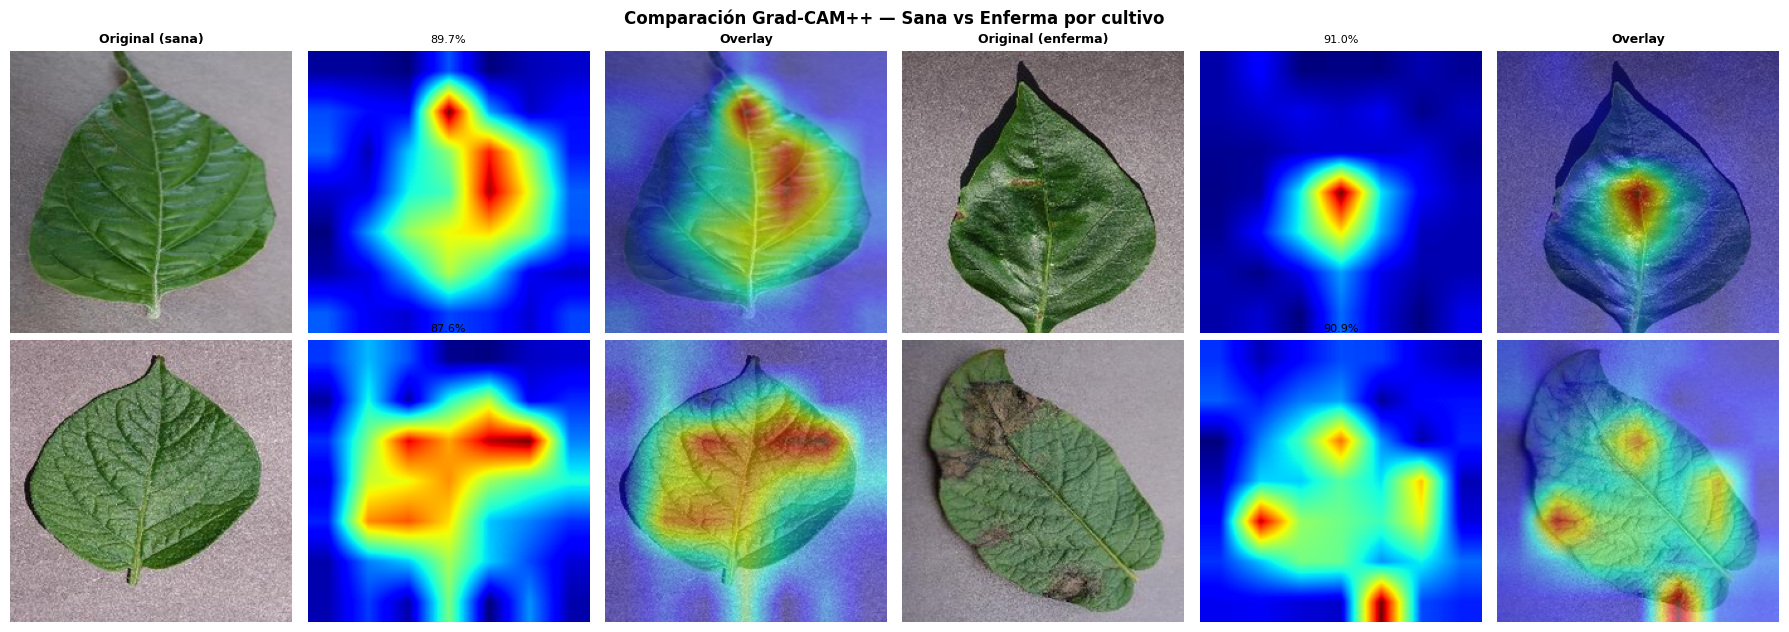

✅ fig9_gradcam_comparativo.png guardada


In [8]:
import random, matplotlib.pyplot as plt

random.seed(7)

# Encontrar pares sana/enferma del mismo cultivo
pares = []
for clase in classes_in_test:
    if 'healthy' in clase.lower():
        cultivo = clase.split('___')[0]
        # Buscar versión enferma del mismo cultivo
        enfermas = [
            c for c in classes_in_test
            if c.startswith(cultivo) and 'healthy' not in c.lower()
        ]
        if enfermas:
            pares.append((clase, enfermas[0]))

if not pares:
    print('⚠️  No se encontraron pares sana/enferma. Verifica los nombres de clases.')
else:
    print(f'Pares encontrados: {len(pares)}')
    for s, e in pares:
        print(f'  • {label_legible(s):30s} ↔ {label_legible(e)}')

    fig, axes = plt.subplots(len(pares), 6, figsize=(6 * 3, len(pares) * 3.2))
    if len(pares) == 1:
        axes = [axes]

    col_headers = ['Original (sana)', 'Heatmap', 'Overlay',
                   'Original (enferma)', 'Heatmap', 'Overlay']
    for ax, h in zip(axes[0], col_headers):
        ax.set_title(h, fontsize=9, fontweight='bold')

    fig.suptitle('Comparación Grad-CAM++ — Sana vs Enferma por cultivo',
                 fontsize=12, fontweight='bold')

    for row_idx, (clase_sana, clase_enferma) in enumerate(pares):
        for col_offset, clase in enumerate([clase_sana, clase_enferma]):
            clase_dir = SPLIT_DIR / 'test' / clase
            imgs = list(clase_dir.glob('*.jpg')) + list(clase_dir.glob('*.JPG'))
            if not imgs:
                continue
            img_path = random.choice(imgs)
            try:
                res = predict_with_gradcam(str(img_path))
            except Exception as e:
                print(f'Error: {e}')
                continue

            base = col_offset * 3
            color = '#1a6b35' if col_offset == 0 else '#8b1a1a'

            axes[row_idx][base].imshow(res['original'])
            axes[row_idx][base].axis('off')
            axes[row_idx][base].set_ylabel(
                label_legible(clase), fontsize=8, color=color,
                fontweight='bold', rotation=0, labelpad=75, va='center'
            )

            axes[row_idx][base + 1].imshow(res['cam_mask'], cmap='jet', vmin=0, vmax=1)
            axes[row_idx][base + 1].axis('off')
            axes[row_idx][base + 1].set_title(
                f"{res['confidence']*100:.1f}%", fontsize=8
            )

            axes[row_idx][base + 2].imshow(res['overlay'])
            axes[row_idx][base + 2].axis('off')

    plt.tight_layout()
    plt.savefig('/content/fig9_gradcam_comparativo.png', dpi=130, bbox_inches='tight')
    plt.show()
    print('✅ fig9_gradcam_comparativo.png guardada')

## 7. Probar diferentes variantes de CAM

Comparar GradCAM, GradCAM++ y EigenCAM sobre la misma imagen para el informe.

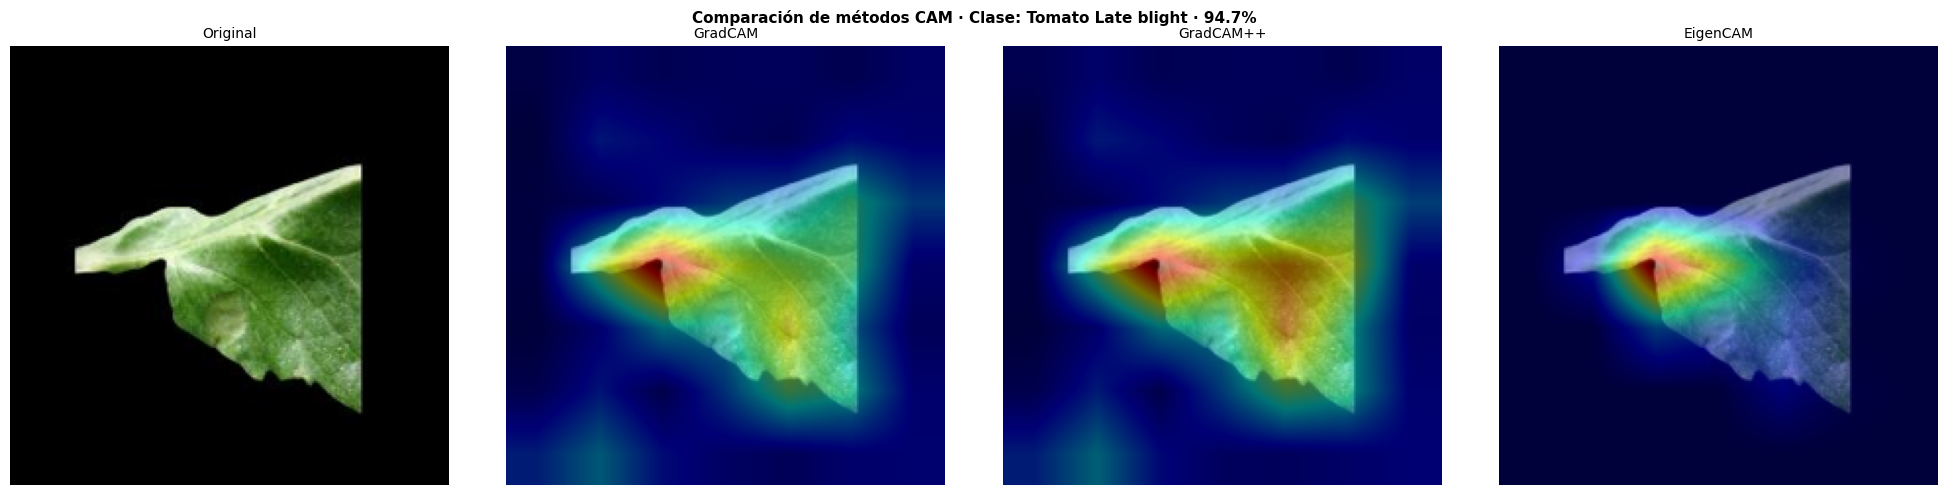

✅ fig10_cam_variants.png guardada

💡 Para el informe: usar GradCAM++ (más preciso para manchas pequeñas en hojas)


In [9]:
from pytorch_grad_cam import GradCAM, GradCAMPlusPlus, EigenCAM
import random, matplotlib.pyplot as plt

random.seed(99)
test_imgs_all = list((SPLIT_DIR / 'test').rglob('*.jpg'))
# Intentar tomar una imagen de planta enferma para que sea más interesante
enfermas = [p for p in test_imgs_all if 'healthy' not in str(p)]
sample   = random.choice(enfermas if enfermas else test_imgs_all)

variantes = {
    'GradCAM'    : GradCAM(model=model, target_layers=target_layers),
    'GradCAM++'  : GradCAMPlusPlus(model=model, target_layers=target_layers),
    'EigenCAM'   : EigenCAM(model=model, target_layers=target_layers),
}

img_pil = PILImage.open(sample).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
img_np  = np.array(img_pil) / 255.0
tensor  = transform_eval(img_pil).unsqueeze(0).to(DEVICE)

with torch.no_grad():
    logits = model(tensor)
    pred_idx = logits.argmax(1).item()
    conf     = F.softmax(logits, 1).cpu().numpy()[0][pred_idx]

fig, axes = plt.subplots(1, len(variantes) + 1, figsize=(5 * (len(variantes) + 1), 5))
fig.suptitle(
    f'Comparación de métodos CAM · Clase: {IDX_TO_LABEL[pred_idx]} · {conf*100:.1f}%',
    fontsize=11, fontweight='bold'
)

axes[0].imshow(img_pil)
axes[0].set_title('Original', fontsize=10)
axes[0].axis('off')

for ax, (name, cam_obj) in zip(axes[1:], variantes.items()):
    mask    = cam_obj(input_tensor=tensor, targets=[ClassifierOutputTarget(pred_idx)])[0]
    mask    = np.clip(mask, 0, 1)
    overlay = show_cam_on_image(img_np.astype(np.float32), mask, use_rgb=True, image_weight=0.55)
    ax.imshow(overlay)
    ax.set_title(name, fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig('/content/fig10_cam_variants.png', dpi=130, bbox_inches='tight')
plt.show()
print('✅ fig10_cam_variants.png guardada')
print('\n💡 Para el informe: usar GradCAM++ (más preciso para manchas pequeñas en hojas)')

## 8. Generar dataset de descripciones para la Fase 4

Procesa N imágenes del test set, guarda las predicciones + descripciones de zona activa
en un JSON. La Fase 4 (LLM) leerá este archivo para generar las explicaciones en lenguaje natural.

In [10]:
import json, random
from tqdm import tqdm

random.seed(42)
N_SAMPLES_PER_CLASS = 5   # imágenes a procesar por clase (ajustar según tiempo disponible)

gradcam_results = []   # lista de dicts que leerá la Fase 4

for clase in classes_in_test:
    clase_dir = SPLIT_DIR / 'test' / clase
    imgs = list(clase_dir.glob('*.jpg')) + list(clase_dir.glob('*.JPG')) + \
           list(clase_dir.glob('*.png'))
    muestra = random.sample(imgs, min(N_SAMPLES_PER_CLASS, len(imgs)))

    for img_path in tqdm(muestra, desc=f'{label_legible(clase)[:30]:30s}', leave=False):
        try:
            res = predict_with_gradcam(str(img_path))

            # Guardar overlay en /content/gradcam_imgs/
            out_dir = Path('/content/gradcam_imgs') / clase
            out_dir.mkdir(parents=True, exist_ok=True)
            overlay_path = out_dir / f"{img_path.stem}_gradcam.png"
            res['overlay'].save(str(overlay_path))

            gradcam_results.append({
                'image_path'     : str(img_path),
                'overlay_path'   : str(overlay_path),
                'true_class'     : clase,
                'true_label'     : label_legible(clase),
                'pred_class'     : res['class_name'],
                'pred_label'     : res['class_label'],
                'confidence'     : round(res['confidence'], 4),
                'correct'        : res['class_name'] == clase,
                'zone_description': res['zone_description'],
                'top3_preds'     : [
                    {'class': CLASS_NAMES[i], 'label': IDX_TO_LABEL[i],
                     'prob': round(float(res['all_probs'][i]), 4)}
                    for i in res['all_probs'].argsort()[::-1][:3]
                ],
            })
        except Exception as e:
            print(f'  ⚠️  Error en {img_path.name}: {e}')

# Guardar JSON para la Fase 4
out_json = ARTIFACTS / 'gradcam_results.json'
with open(out_json, 'w', encoding='utf-8') as f:
    json.dump(gradcam_results, f, indent=2, ensure_ascii=False)

correctos  = sum(r['correct'] for r in gradcam_results)
total_proc = len(gradcam_results)
print(f'\n✅ Procesadas {total_proc} imágenes')
print(f'   Correctas  : {correctos}/{total_proc} ({100*correctos/total_proc:.1f}%)')
print(f'   JSON guardado en: {out_json}')


✅ Procesadas 30 imágenes
   Correctas  : 30/30 (100.0%)
   JSON guardado en: /content/artifacts/gradcam_results.json


## 9. Guardar todo en Google Drive

In [11]:
import zipfile

# ── Artefactos JSON ───────────────────────────────────────────────────────────
print('Sincronizando artefactos a Google Drive...')
save_to_drive(ARTIFACTS / 'gradcam_results.json', subfolder='artifacts')

# ── Figuras ───────────────────────────────────────────────────────────────────
print('\nSincronizando figuras...')
for fig_name in ['fig8_gradcam_gallery', 'fig9_gradcam_comparativo', 'fig10_cam_variants']:
    save_to_drive(f'/content/{fig_name}.png', subfolder='figures')

# ── Imágenes Grad-CAM individuales (zip) ──────────────────────────────────────
print('\nComprimiendo imágenes Grad-CAM individuales...')
gradcam_zip = ARTIFACTS / 'gradcam_imgs.zip'
gradcam_imgs_dir = Path('/content/gradcam_imgs')
if gradcam_imgs_dir.exists():
    with zipfile.ZipFile(gradcam_zip, 'w', zipfile.ZIP_DEFLATED) as zf:
        for f in sorted(gradcam_imgs_dir.rglob('*.png')):
            zf.write(f, f.relative_to(gradcam_imgs_dir.parent))
    save_to_drive(gradcam_zip, subfolder='artifacts')

print()
print('━' * 55)
print('  FASE 3 COMPLETADA ✅')
print('━' * 55)
print(f'  Método        : GradCAM++ sobre layer4 de ResNet-50')
print(f'  Imágenes proc.: {len(gradcam_results)}')
print(f'  Clases        : {len(classes_in_test)}')
print()
print('  Artefactos en Drive/IA_EAFIT/')
print('    artifacts/gradcam_results.json   ← input para Fase 4 (LLM)')
print('    artifacts/gradcam_imgs.zip       ← overlays individuales')
print('    figures/fig8_gradcam_gallery.png')
print('    figures/fig9_gradcam_comparativo.png')
print('    figures/fig10_cam_variants.png')
print()
print('  Siguiente paso → Fase 4: LLM con Groq')


Sincronizando artefactos a Google Drive...
  ✅ gradcam_results.json                     → Drive/artifacts/ (32.5 KB)

Sincronizando figuras...
  ✅ fig8_gradcam_gallery.png                 → Drive/figures/ (4057.4 KB)
  ✅ fig9_gradcam_comparativo.png             → Drive/figures/ (2005.2 KB)
  ✅ fig10_cam_variants.png                   → Drive/figures/ (527.7 KB)

Comprimiendo imágenes Grad-CAM individuales...
  ✅ gradcam_imgs.zip                         → Drive/artifacts/ (2871.6 KB)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  FASE 3 COMPLETADA ✅
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Método        : GradCAM++ sobre layer4 de ResNet-50
  Imágenes proc.: 30
  Clases        : 6

  Artefactos en Drive/IA_EAFIT/
    artifacts/gradcam_results.json   ← input para Fase 4 (LLM)
    artifacts/gradcam_imgs.zip       ← overlays individuales
    figures/fig8_gradcam_gallery.png
    figures/fig9_gradcam_comparativo.png
    figures/fig10_cam_variants.png

  Siguiente

---
## Notas para el informe (Sección 3.1 — Componentes principales)

### Párrafo sugerido para el informe:

> Se aplicó **Grad-CAM++** (Chattopadhay et al., 2018) sobre la capa `layer4` de ResNet-50,
> que produce mapas de activación de 7×7 píxeles interpolados bilinealmente a 224×224.
> Grad-CAM++ fue preferido sobre Grad-CAM original por su mayor precisión en la localización
> de manchas pequeñas y múltiples regiones de interés dentro de una misma imagen.
> El mapa de calor resultante se superpone con transparencia α=0.45 sobre la imagen original
> usando el colormap JET, donde el rojo indica alta activación y el azul baja activación.

### Hallazgos a mencionar:
1. **Plantas enfermas:** el modelo activa consistentemente las zonas con manchas, necrosis o decoloración.
2. **Plantas sanas:** la activación es más difusa, distribuida sobre la textura general de la hoja.
3. **Comparación de métodos CAM** (fig10): GradCAM++ produce mapas más focalizados que GradCAM y EigenCAM para este dominio.

### Referencia a agregar en el informe:
```
Chattopadhay, A., et al. (2018). Grad-CAM++: Generalized Gradient-based Visual
Explanations for Deep Convolutional Networks. WACV 2018.
https://arxiv.org/abs/1710.11063
```
